In [1]:
%pip install torch torchvision transformers timm pillow reportlab matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cpu
Loading model and weights...


Loading weights: 100%|██████████| 223/223 [00:02<00:00, 95.82it/s]


Model loaded successfully!



Could not reach the Hub ([WinError 10054] An existing connection was forcibly closed by the remote host). Using cached commit hash for 'facebook/dinov2-base'.


Starting batch prediction on 6 sample(s)...



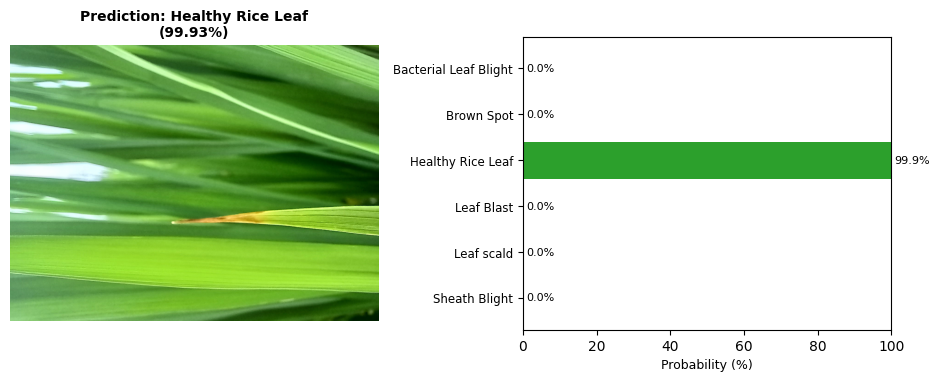

[1/6] File: He.jpg
Diagnosis : Healthy Rice Leaf
Confidence: 99.93%
------------------------------------------------
  Bacterial Leaf Blight   : 0.05%
  Brown Spot              : 0.00%
  Healthy Rice Leaf       : 99.93%
  Leaf Blast              : 0.00%
  Leaf scald              : 0.01%
  Sheath Blight           : 0.00%



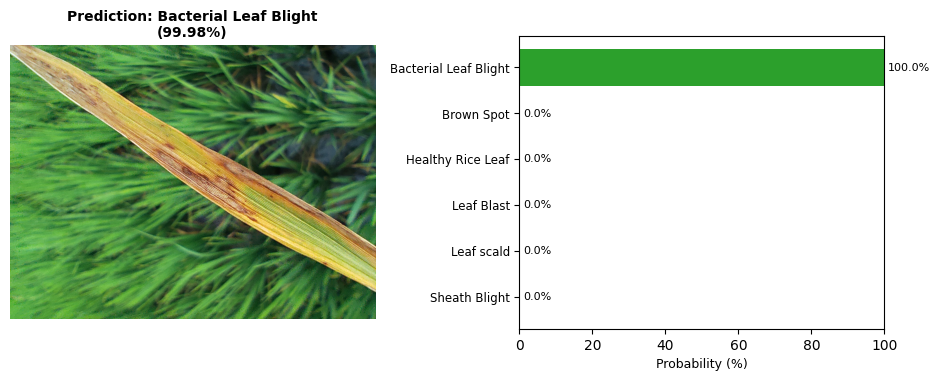

[2/6] File: BLB.jpg
Diagnosis : Bacterial Leaf Blight
Confidence: 99.98%
------------------------------------------------
  Bacterial Leaf Blight   : 99.98%
  Brown Spot              : 0.00%
  Healthy Rice Leaf       : 0.01%
  Leaf Blast              : 0.00%
  Leaf scald              : 0.01%
  Sheath Blight           : 0.01%



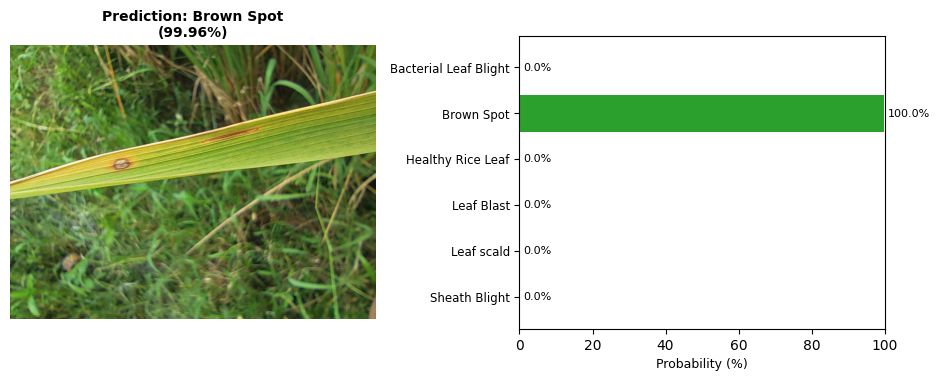

[3/6] File: BS.jpg
Diagnosis : Brown Spot
Confidence: 99.96%
------------------------------------------------
  Bacterial Leaf Blight   : 0.02%
  Brown Spot              : 99.96%
  Healthy Rice Leaf       : 0.00%
  Leaf Blast              : 0.00%
  Leaf scald              : 0.01%
  Sheath Blight           : 0.00%



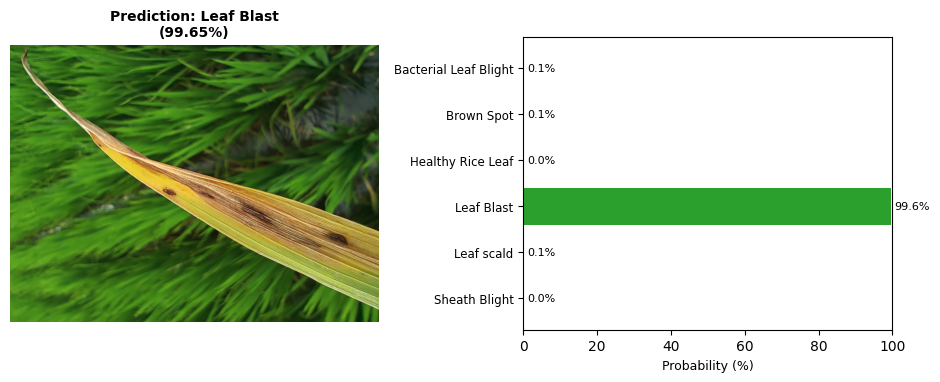

[4/6] File: LB.jpg
Diagnosis : Leaf Blast
Confidence: 99.65%
------------------------------------------------
  Bacterial Leaf Blight   : 0.08%
  Brown Spot              : 0.14%
  Healthy Rice Leaf       : 0.03%
  Leaf Blast              : 99.65%
  Leaf scald              : 0.09%
  Sheath Blight           : 0.01%



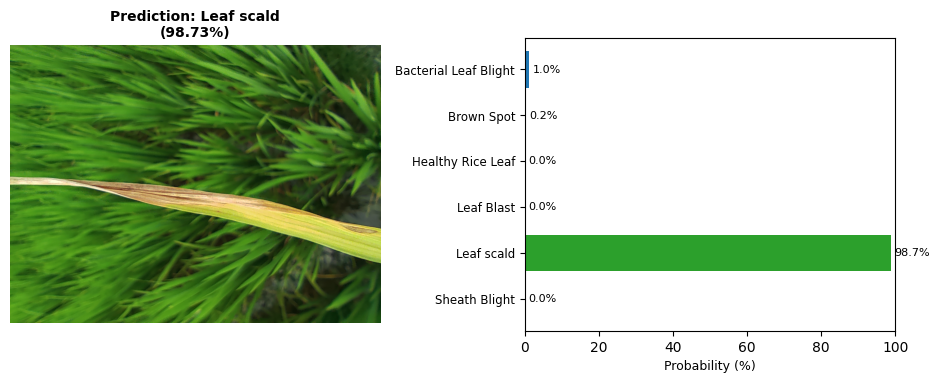

[5/6] File: LS.jpg
Diagnosis : Leaf scald
Confidence: 98.73%
------------------------------------------------
  Bacterial Leaf Blight   : 1.03%
  Brown Spot              : 0.19%
  Healthy Rice Leaf       : 0.04%
  Leaf Blast              : 0.01%
  Leaf scald              : 98.73%
  Sheath Blight           : 0.01%



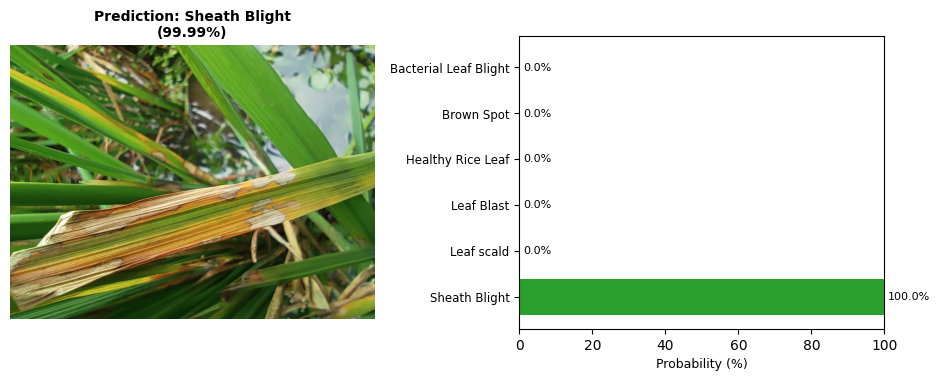

[6/6] File: SB.jpg
Diagnosis : Sheath Blight
Confidence: 99.99%
------------------------------------------------
  Bacterial Leaf Blight   : 0.00%
  Brown Spot              : 0.00%
  Healthy Rice Leaf       : 0.00%
  Leaf Blast              : 0.00%
  Leaf scald              : 0.00%
  Sheath Blight           : 99.99%


Report created successfully: rice_leaf_disease_complete_report.pdf


In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt

# ReportLab modules for PDF generation
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image as ReportLabImage,
    PageBreak
)

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Canonical class names (matching ImageFolder alphabetical order)
CLASS_NAMES = [
    "Bacterial Leaf Blight",
    "Brown Spot",
    "Healthy Rice Leaf",
    "Leaf Blast",
    "Leaf scald",
    "Sheath Blight"
]
NUM_CLASSES = len(CLASS_NAMES)

# 3. DINOv2 Architecture Definition
class DINOv2Classifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_dim = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        return self.classifier(outputs.last_hidden_state[:, 0, :])

HF_MODEL_NAME = "facebook/dinov2-base"
CHECKPOINT_PATH = "best_dinov2_rice_model.pth"

# 4. Load Model and Weights with version-compatibility remap
print("Loading model and weights...")
model = DINOv2Classifier(HF_MODEL_NAME, NUM_CLASSES)
raw_state_dict = torch.load(CHECKPOINT_PATH, map_location=device)

# Remap legacy attention key names from Kaggle's older transformers version
remapped_state_dict = {}
for key, value in raw_state_dict.items():
    new_key = key
    new_key = new_key.replace("attention.attention.query", "attention.q_proj")
    new_key = new_key.replace("attention.attention.key", "attention.k_proj")
    new_key = new_key.replace("attention.attention.value", "attention.v_proj")
    new_key = new_key.replace("attention.output.dense", "attention.o_proj")
    remapped_state_dict[new_key] = value

model.load_state_dict(remapped_state_dict)
model.to(device)
model.eval()
print("Model loaded successfully!\n")

# 5. Image Preprocessing (matching DINOv2 processor norms)
processor = AutoImageProcessor.from_pretrained(HF_MODEL_NAME)
norm_mean = processor.image_mean if hasattr(processor, "image_mean") else [0.485, 0.456, 0.406]
norm_std = processor.image_std if hasattr(processor, "image_std") else [0.229, 0.224, 0.225]

predict_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# Helper to automatically resolve image extensions (.jpg, .jpeg, .png)
def resolve_image_path(base_name: str):
    if os.path.exists(base_name):
        return base_name
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
        candidate = f"{base_name}{ext}"
        if os.path.exists(candidate):
            return candidate
    return None

# 6. Prediction and PDF Generation Function
def generate_combined_leaf_report(image_files: list, output_pdf_name: str = "rice_leaf_disease_complete_report.pdf"):
    styles = getSampleStyleSheet()
    title_style = ParagraphStyle("MainTitle", parent=styles["Title"], fontSize=18, leading=22, spaceAfter=6)
    sub_style = ParagraphStyle("SubTitle", parent=styles["Normal"], fontSize=9, textColor=colors.dimgrey, spaceAfter=10)
    h2_style = ParagraphStyle("Heading2", parent=styles["Heading2"], fontSize=11, leading=14, spaceBefore=6, spaceAfter=4)
    cell_style = ParagraphStyle("TableCell", parent=styles["Normal"], fontSize=8.5, leading=11)

    story = []
    temp_image_files = []

    # Filter out missing files
    valid_images = []
    for f in image_files:
        resolved = resolve_image_path(f)
        if resolved:
            valid_images.append(resolved)
        else:
            print(f"Warning: File '{f}' (or {f}.jpg/.png) not found. Skipping...")

    if not valid_images:
        print("Error: None of the target image files were found in the current working directory.")
        return

    print(f"Starting batch prediction on {len(valid_images)} sample(s)...\n")

    for i, img_path in enumerate(valid_images):
        image = Image.open(img_path).convert("RGB")
        tensor = predict_transforms(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(tensor)
            probabilities = F.softmax(outputs, dim=1)[0]

        conf, pred_idx = torch.max(probabilities, dim=0)
        predicted_label = CLASS_NAMES[pred_idx.item()]
        confidence_score = conf.item() * 100

        # Plot Console Figures (Sample Image + Probability Bar Chart)
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

        axes[0].imshow(image)
        axes[0].set_title(f"Prediction: {predicted_label}\n({confidence_score:.2f}%)", fontsize=10, fontweight="bold")
        axes[0].axis("off")

        scores = [probabilities[idx].item() * 100 for idx in range(len(CLASS_NAMES))]
        bar_colors = ['#2ca02c' if idx == pred_idx else '#1f77b4' for idx in range(len(CLASS_NAMES))]

        axes[1].barh(range(len(CLASS_NAMES)), scores, color=bar_colors)
        axes[1].set_yticks(range(len(CLASS_NAMES)))
        axes[1].set_yticklabels(CLASS_NAMES, fontsize=8.5)
        axes[1].invert_yaxis()
        axes[1].set_xlabel("Probability (%)", fontsize=9)
        axes[1].set_xlim(0, 100)

        for bar_idx, val in enumerate(scores):
            axes[1].text(val + 1, bar_idx, f"{val:.1f}%", va='center', fontsize=8)

        plt.tight_layout()

        temp_fig_path = f"_temp_dinov2_{i}.png"
        temp_image_files.append(temp_fig_path)
        plt.savefig(temp_fig_path, dpi=200, bbox_inches="tight")
        plt.show()

        # Terminal Print
        print("=" * 48)
        print(f"[{i+1}/{len(valid_images)}] File: {img_path}")
        print(f"Diagnosis : {predicted_label}")
        print(f"Confidence: {confidence_score:.2f}%")
        print("-" * 48)
        for idx, name in enumerate(CLASS_NAMES):
            print(f"  {name:<24}: {probabilities[idx].item()*100:.2f}%")
        print("=" * 48 + "\n")

        # --- ReportLab Page Layout ---
        story.append(Paragraph(f"Rice Leaf Health Diagnosis — Sample {i+1}", title_style))
        story.append(Paragraph(f"Model: {HF_MODEL_NAME} (DINOv2) | Input File: {img_path}", sub_style))

        status_text = "Healthy" if "Healthy" in predicted_label else "Disease Detected"
        status_color = "#27ae60" if "Healthy" in predicted_label else "#c0392b"

        summary_data = [
            [Paragraph("<b>Target Image</b>", cell_style), Paragraph(str(img_path), cell_style)],
            [Paragraph("<b>Diagnostic Result</b>", cell_style), Paragraph(f"<b>{predicted_label}</b>", cell_style)],
            [Paragraph("<b>Confidence Score</b>", cell_style), Paragraph(f"<b>{confidence_score:.2f}%</b>", cell_style)],
            [Paragraph("<b>Pathology Status</b>", cell_style), Paragraph(f"<font color='{status_color}'><b>{status_text}</b></font>", cell_style)]
        ]

        summary_table = Table(summary_data, colWidths=[130, 390])
        summary_table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, -1), colors.whitesmoke),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.lightgrey),
            ('TOPPADDING', (0, 0), (-1, -1), 3),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 3),
        ]))
        story.append(summary_table)
        story.append(Spacer(1, 10))

        story.append(ReportLabImage(temp_fig_path, width=490, height=195))
        story.append(Spacer(1, 8))

        story.append(Paragraph("Full Probability Distribution", h2_style))
        prob_rows = [["Disease Class", "Probability Score (%)"]]
        for idx, name in enumerate(CLASS_NAMES):
            prob_rows.append([name, f"{probabilities[idx].item()*100:.2f}%"])

        prob_table = Table(prob_rows, colWidths=[330, 190])
        prob_table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor("#2C3E50")),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
            ('ALIGN', (1, 1), (-1, -1), 'CENTER'),
            ('TOPPADDING', (0, 0), (-1, -1), 3),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 3),
        ]))
        story.append(prob_table)

        if i < len(valid_images) - 1:
            story.append(PageBreak())

    # Build PDF
    doc = SimpleDocTemplate(
        output_pdf_name,
        pagesize=A4,
        rightMargin=36,
        leftMargin=36,
        topMargin=36,
        bottomMargin=36
    )
    doc.build(story)

    # Cleanup temporary images
    for temp_f in temp_image_files:
        if os.path.exists(temp_f):
            os.remove(temp_f)

    print(f"\nReport created successfully: {output_pdf_name}")

# 7. Short form target names (handles both 'He' and 'He.jpg')
sample_images = [
    "He",   # Healthy Rice Leaf
    "BLB",  # Bacterial Leaf Blight
    "BS",   # Brown Spot
    "LB",   # Leaf Blast
    "LS",   # Leaf Scald
    "SB"    # Sheath Blight
]

generate_combined_leaf_report(sample_images, output_pdf_name="rice_leaf_disease_complete_report.pdf")